In [1]:
# HEALTHCARE PREDICTIVE ANALYTICS
# DIABETES DISEASE DETECTION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)


In [2]:
# LOAD DATASET

df = pd.read_csv(r"D:\Self_project\Health_Care\Healthcare_analysis_Project\dataset\healthcare_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [4]:
df.dropna(axis=0)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [5]:
df.dtypes

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object

In [6]:
df.shape

(55500, 15)

In [7]:
df.describe

<bound method NDFrame.describe of                     Name  Age  Gender Blood Type Medical Condition  \
0          Bobby JacksOn   30    Male         B-            Cancer   
1           LesLie TErRy   62    Male         A+           Obesity   
2            DaNnY sMitH   76  Female         A-           Obesity   
3           andrEw waTtS   28  Female         O+          Diabetes   
4          adrIENNE bEll   43  Female        AB+            Cancer   
...                  ...  ...     ...        ...               ...   
55495  eLIZABeTH jaCkSOn   42  Female         O+            Asthma   
55496         KYle pEREz   61  Female        AB-           Obesity   
55497       HEATher WaNG   38  Female         B+      Hypertension   
55498     JENniFER JOneS   43    Male         O-         Arthritis   
55499       jAMES GARCiA   53  Female         O+         Arthritis   

      Date of Admission            Doctor                      Hospital  \
0            2024-01-31     Matthew Smith         

In [8]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 534


In [10]:
df.columns.tolist()

['Name',
 'Age',
 'Gender',
 'Blood Type',
 'Medical Condition',
 'Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Room Number',
 'Admission Type',
 'Discharge Date',
 'Medication',
 'Test Results']

In [11]:
target = "Medical Condition"                                   #Find the Target Column


In [12]:
df["Medical Condition"].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

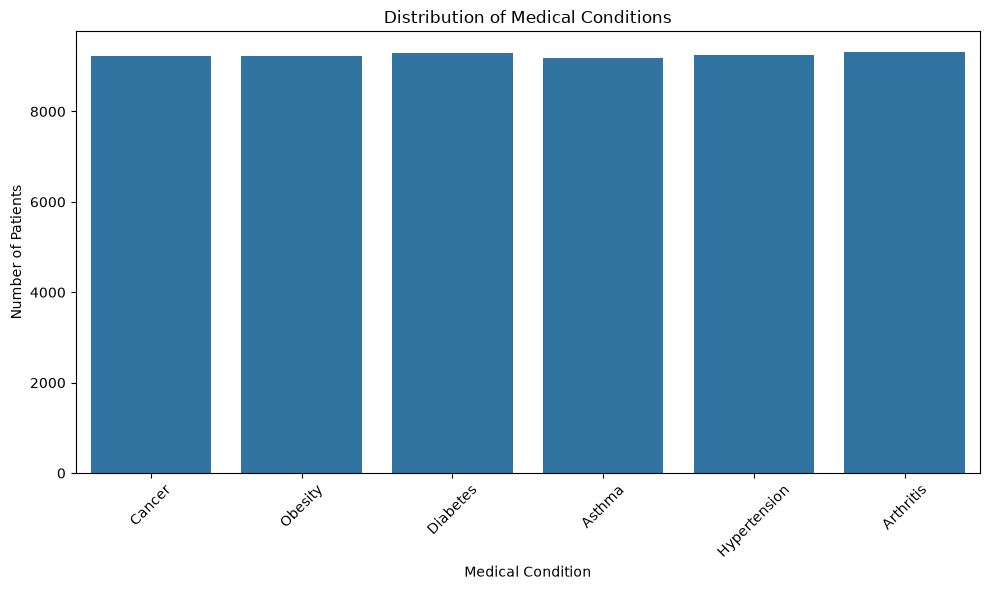

In [13]:
plt.figure(figsize=(10, 6))                                        #Check Disease Distribution

sns.countplot(
    data=df,
    x="Medical Condition"
)

plt.title("Distribution of Medical Conditions")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

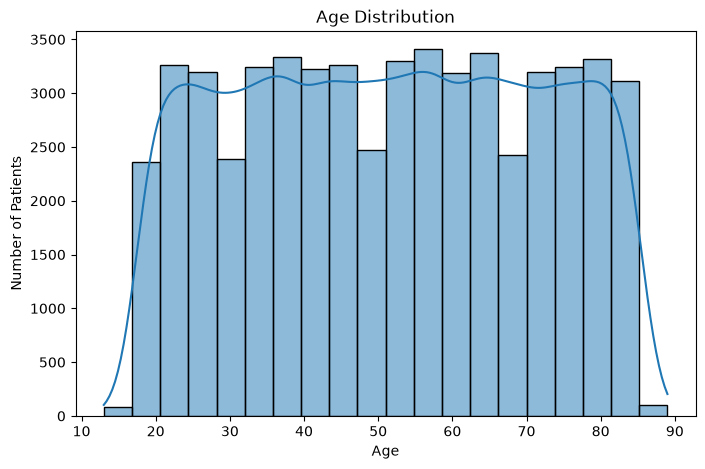

In [14]:
plt.figure(figsize=(8, 5))                             #age distribution

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

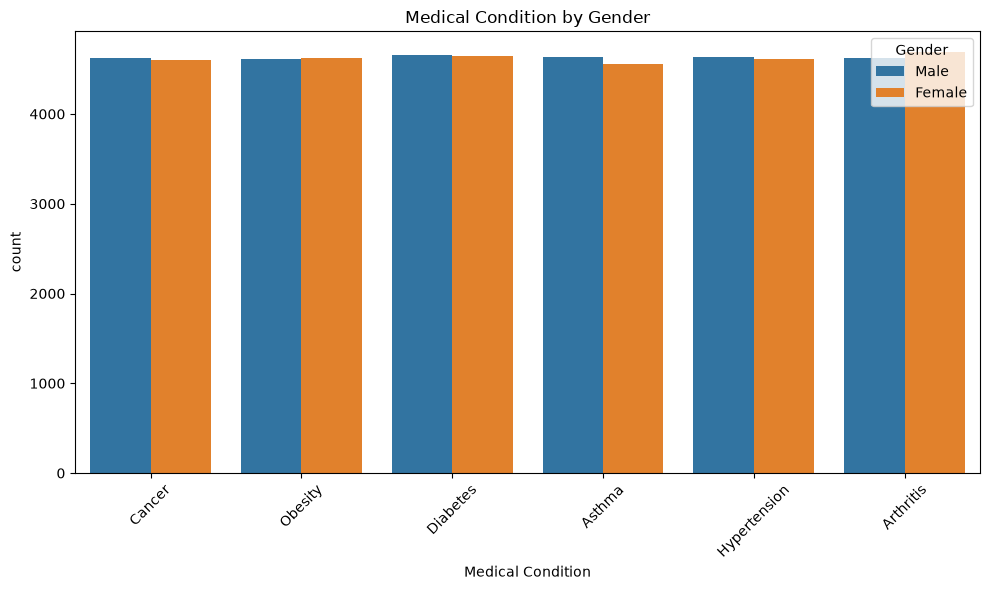

In [15]:
plt.figure(figsize=(10, 6))                           #Gender vs Medical Condition

sns.countplot(
    data=df,
    x="Medical Condition",
    hue="Gender"
)

plt.title("Medical Condition by Gender")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

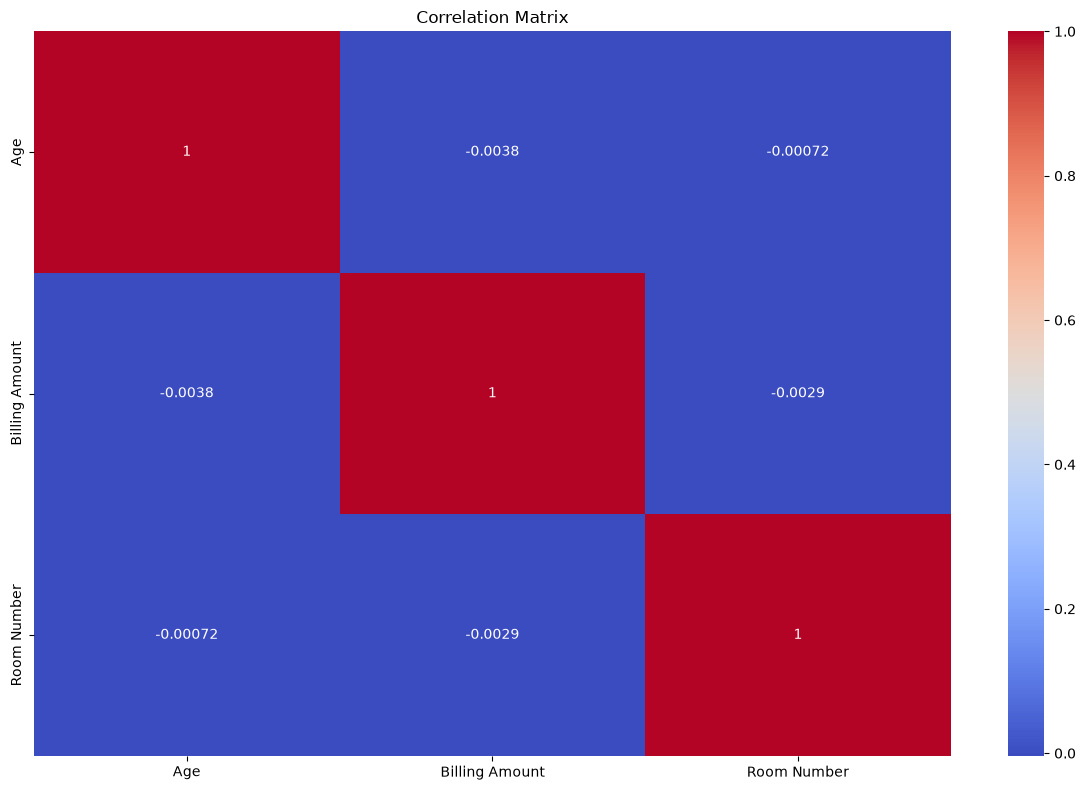

In [16]:
numeric_df = df.select_dtypes(include=np.number)                                   #Correlation Analysis

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

HEALTHCARE PREDICTIVE ANALYTICS

Loading dataset...
Dataset loaded successfully!
Rows: 55500
Columns: 15

Columns:
['Name', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition', 'Date_of_Admission', 'Doctor', 'Hospital', 'Insurance_Provider', 'Billing_Amount', 'Room_Number', 'Admission_Type', 'Discharge_Date', 'Medication', 'Test_Results']

Target column: Medical_Condition

Duplicates removed: 534
Rows after target cleaning: 54966

Removing non-predictive columns:
['Name', 'Doctor', 'Hospital', 'Insurance_Provider', 'Billing_Amount', 'Room_Number', 'Date_of_Admission', 'Discharge_Date']

Numeric features:
['Age']

Categorical features:
['Gender', 'Blood_Type', 'Admission_Type', 'Medication', 'Test_Results']

Training samples: 43972
Testing samples: 10994

Training: Logistic Regression
Accuracy : 0.1619
Precision: 0.1616
Recall   : 0.1619
F1 Score : 0.1585

Classification Report:
              precision    recall  f1-score   support

   Arthritis       0.17      0.18      0.18      1844
 

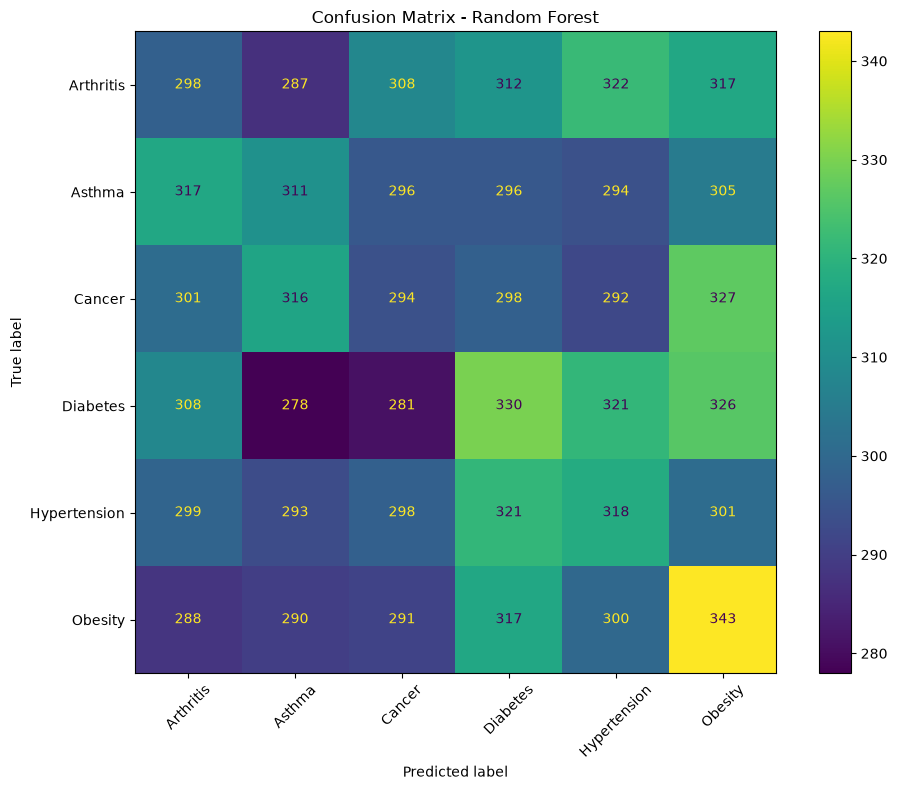


Top 20 Important Features:
                                   Feature  Importance
0                             numeric__Age    0.853858
20  categorical__Test_Results_Inconclusive    0.008470
19      categorical__Test_Results_Abnormal    0.008175
2                 categorical__Gender_Male    0.008061
1               categorical__Gender_Female    0.008051
21        categorical__Test_Results_Normal    0.007739
8               categorical__Blood_Type_B-    0.007442
10              categorical__Blood_Type_O-    0.007360
9               categorical__Blood_Type_O+    0.007194
15       categorical__Medication_Ibuprofen    0.007079
7               categorical__Blood_Type_B+    0.006959
6              categorical__Blood_Type_AB-    0.006861
18      categorical__Medication_Penicillin    0.006830
5              categorical__Blood_Type_AB+    0.006766
4               categorical__Blood_Type_A-    0.006666
16         categorical__Medication_Lipitor    0.006466
17     categorical__Medication_Parace

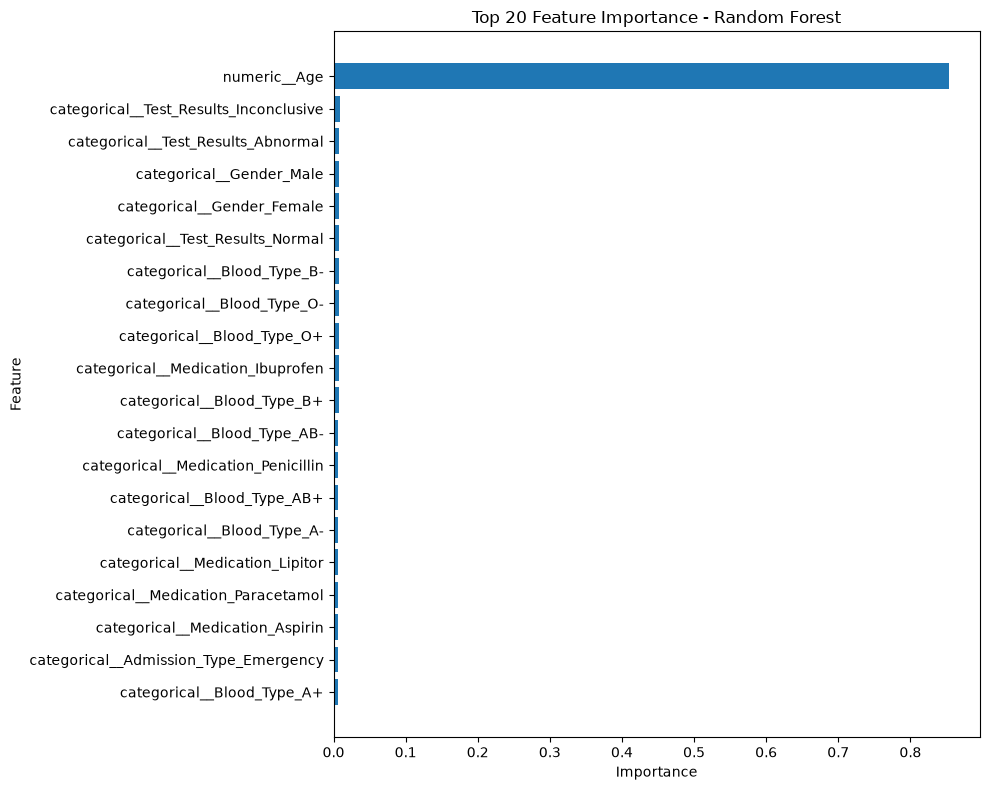


Training completed successfully!


In [17]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
warnings.filterwarnings("ignore")
# ============================================================
# 1. PATHS
# ============================================================
DATA_PATH =r"C:\Users\sutra\Downloads\dataset\healthcare_dataset.csv"
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "models"
RESULT_DIR = PROJECT_ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
# ============================================================
# 2. LOAD DATA
# ============================================================
print("=" * 60)
print("HEALTHCARE PREDICTIVE ANALYTICS")
print("=" * 60)
print("\nLoading dataset...")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
# ============================================================
# 3. CLEAN COLUMN NAMES
# ============================================================
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("%", "Percent")
)
print("\nColumns:")
print(df.columns.tolist())
# ============================================================
# 4. TARGET COLUMN
# ============================================================
possible_targets = [
    "Medical_Condition",
    "MedicalCondition",
    "Disease",
    "Diagnosis",
    "Target"
]
target = None
for column in possible_targets:
    if column in df.columns:
        target = column
        break
if target is None:
    raise ValueError(
        "Target column not found. "
        "Expected one of: " + str(possible_targets)
    )
print("\nTarget column:", target)
# ============================================================
# 5. REMOVE DUPLICATES
# ============================================================
before = len(df)
df = df.drop_duplicates()
after = len(df)
print("\nDuplicates removed:", before - after)
# ============================================================
# 6. REMOVE EMPTY TARGET VALUES
# ============================================================
df = df.dropna(subset=[target])
print("Rows after target cleaning:", len(df))
# ============================================================
# 7. SEPARATE FEATURES AND TARGET
# ============================================================
X = df.drop(columns=[target])
y = df[target]
# ============================================================
# 8. REMOVE IDENTIFIER / LEAKAGE COLUMNS
# ============================================================
columns_to_remove = []
possible_identifier_columns = [
    "Name",
    "Patient_ID",
    "PatientID",
    "Doctor",
    "Hospital",
    "Insurance_Provider",
    "Billing_Amount",
    "Room_Number",
    "Date_of_Admission",
    "Discharge_Date"
]
for column in possible_identifier_columns:
    if column in X.columns:
        columns_to_remove.append(column)
if columns_to_remove:
    print("\nRemoving non-predictive columns:")
    print(columns_to_remove)
    X = X.drop(columns=columns_to_remove)
# ============================================================
# 9. IDENTIFY DATA TYPES
# ============================================================
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()
categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()
print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
# ============================================================
# 10. PREPROCESSING
# ============================================================
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)
# ============================================================
# 11. TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))
# ============================================================
# 12. MODELS
# ============================================================
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}
# ============================================================
# 13. TRAIN MODELS
# ============================================================
results = []
trained_pipelines = {}
for model_name, model in models.items():
    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )
    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1
        }
    )
    trained_pipelines[model_name] = pipeline
# ============================================================
# 14. MODEL COMPARISON
# ============================================================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1_Score",
    ascending=False
)
print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df)
# Save results
results_df.to_csv(
    RESULT_DIR / "model_comparison.csv",
    index=False
)
# ============================================================
# 15. SELECT BEST MODEL
# ============================================================
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[
    best_model_name
]
print("\nBest Model:", best_model_name)
# ============================================================
# 16. SAVE BEST MODEL
# ============================================================

model_path = MODEL_DIR / "healthcare_disease_model.pkl"
joblib.dump(
    best_pipeline,
    model_path
)
print(
    "\nModel saved to:",
    model_path
)
# ============================================================
# 17. CONFUSION MATRIX
# ============================================================
best_predictions = best_pipeline.predict(X_test)
cm = confusion_matrix(
    y_test,
    best_predictions
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_pipeline.classes_
)
fig, ax = plt.subplots(
    figsize=(10, 8)
)
disp.plot(
    ax=ax,
    xticks_rotation=45
)
plt.title(
    f"Confusion Matrix - {best_model_name}"
)
plt.tight_layout()
plt.savefig(
    RESULT_DIR / "confusion_matrix.png",
    dpi=300
)
plt.show()
# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================
model = best_pipeline.named_steps["model"]
preprocessor_fitted = (
    best_pipeline.named_steps["preprocessor"]
)
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": importances
        }
    )
    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
    )
    print("\nTop 20 Important Features:")
    print(
        feature_importance_df.head(20)
    )
    feature_importance_df.to_csv(
        RESULT_DIR / "feature_importance.csv",
        index=False
    )
    # Plot top 20
    top_features = (
        feature_importance_df
        .head(20)
        .sort_values("Importance")
    )
    plt.figure(figsize=(10, 8))
    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(
        f"Top 20 Feature Importance - {best_model_name}"
    )
    plt.tight_layout()
    plt.savefig(
        RESULT_DIR / "feature_importance.png",
        dpi=300
    )
    plt.show()
print("\nTraining completed successfully!")